# Pre-Onset Characterization of PAF from RR Intervals Using Statistical Process Control Features
## AFPDB — MEDICON 2026

**Research Question:**  
Can RR-interval-derived features (HRV + SPC) distinguish, *within* subjects with documented PAF,  
the **far-from-onset** segment (`y=0`, p-odd) from the **pre-onset** segment (`y=1`, p-even)  
using only the 30-minute recordings that immediately precede each PAF episode?

**Dataset:** PhysioNet *PAF Prediction Challenge Database* (AFPDB)  
- Records `p01`–`p50` (30-min segments, no `*c` continuation records, no `n*` controls)  
- 25 matched pairs: each pair = (p-odd / far-baseline, p-even / pre-onset)  
- Perfectly balanced: 25 × y=0, 25 × y=1  
- Validation: `GroupKFold(5)` by `pair_id` — no pair leaks across train/val  

**Note on labels:**  
- `y=0` → **far_baseline** (not "normal", not "healthy", not "control")
- `y=1` → **pre_onset**  

---

**Notebook structure:**
1. Setup & dataset audit  
2. Feature extraction pipeline overview  
3. HRV collinearity analysis  
4. Paired delta analysis (far_baseline vs pre_onset)  
5. Multi-scale window evaluation  
6. Feature block comparison (A → E)  
7. Pairwise concordance  
8. Bootstrap 95% CI by pair_id  
9. Temporal feature aggregation  
10. Feature importance and coefficient stability  
11. Figures for publication  
12. Discussion & limitations  

In [1]:
import os, sys, warnings
from pathlib import Path

ROOT = Path(os.getcwd())   # assumes notebook is in Medicons/
sys.path.insert(0, str(ROOT / 'src'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

TABLES   = ROOT / 'artifacts' / 'tables'
REPORTS  = ROOT / 'artifacts' / 'reports'
FIG_DIR  = ROOT / 'artifacts' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
THRESHOLD    = 0.5
N_BOOT       = 500

# Colour palette (accessible)
C0, C1, C2, C3 = '#0072B2', '#E69F00', '#009E73', '#CC79A7'

def savefig(fig, name, dpi=600):
    fig.savefig(FIG_DIR / f'{name}.png', dpi=dpi, bbox_inches='tight')
    fig.savefig(FIG_DIR / f'{name}.tif', dpi=dpi, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print('Setup complete. ROOT:', ROOT)

Setup complete. ROOT: C:\Users\miche\OneDrive\Documentos\Medicons


---
## 1 · Dataset Construction and Audit

In [2]:
from afpdb_multiscale.loader import build_main_manifest

manifest = pd.DataFrame(build_main_manifest())
print(f'Records: {len(manifest)}   Pairs: {manifest.pair_id.nunique()}   '
      f'Balance y=0/y=1: {(manifest.y==0).sum()}/{(manifest.y==1).sum()}')

# Audit: no *c, no n*, correct pair structure
audit_rules = {
    'No *c records in main task' :  not manifest.record_id.str.endswith('c').any(),
    'No n* records in main task' :  not manifest.record_id.str.startswith('n').any(),
    'All records are p*'         :  manifest.record_id.str.startswith('p').all(),
    'Every pair_id has exactly 2': (manifest.groupby('pair_id').size() == 2).all(),
    'Every pair has y=0 and y=1' : (manifest.groupby('pair_id')['y'].nunique() == 2).all(),
    'analysis_task correct'      :  (manifest.analysis_task == 'main_p_far_vs_p_pre').all(),
}
audit_df = pd.DataFrame.from_dict(audit_rules, orient='index', columns=['passed'])
audit_df['status'] = audit_df['passed'].map({True: '✓ PASS', False: '✗ FAIL'})
display(audit_df)

display(manifest.head(6))

Records: 50   Pairs: 25   Balance y=0/y=1: 25/25

,passed,status
No *c records in main task,True,✓ PASS
No n* records in main task,True,✓ PASS
All records are p*,True,✓ PASS
Every pair_id has exactly 2,True,✓ PASS
Every pair has y=0 and y=1,True,✓ PASS
analysis_task correct,True,✓ PASS


,record_id,pair_id,y,analysis_task
0,p01,0,0,main_p_far_vs_p_pre
1,p02,0,1,main_p_far_vs_p_pre
2,p03,1,0,main_p_far_vs_p_pre
3,p04,1,1,main_p_far_vs_p_pre
4,p05,2,0,main_p_far_vs_p_pre
5,p06,2,1,main_p_far_vs_p_pre


---
## 2 · Feature Extraction Pipeline Overview

```
QRS annotations (.qrs)  →  RR intervals (ms)
     ↓
Window segmentation  →  rr_count {50, 100, 128, 200}  |  time {300 s}  |  full_record
     ↓
Per-window features:
  HRV basic     : mean_rr, std_rr, rmssd, sdsd, cv_rr, mad_rr, rr_diff_mean, rr_diff_std
  Poincaré      : sd1, sd2, sd1_sd2_ratio
  SPC / Shewhart: shewhart_out_count, shewhart_out_rate, shewhart_max_abs_z
  SPC / CUSUM ± : cusum_pos_max, cusum_neg_max, cusum_abs_max, cusum_alarm_count,
                  cusum_alarm_density, cusum_time_in_alarm, cusum_first_alarm_time_sec
  SPC / EWMA    : ewma_last, ewma_max_abs, ewma_slope, ewma_alarm_count
  SPC / MR      : mr_mean, mr_median, mr_max, mr_mad, mr_out_count
  Runs rules    : longest_run_above/below_median, trend_run_up/down, violations
  Ectopy-like   : ectopy_like_count/density, bigeminy/trigeminy/tachy-like patterns
     ↓
Aggregation → 1 row per (record, window_type, window_size)
```

**SPC baseline (anti-leakage):** μ and σ estimated from the first `BASELINE_N_RR = 200`  
intervals of each record independently. Control limits do not use future information.  

**Note on ectopy-like features:**  
Variables `ectopy_like_*` are RR-inferred patterns *compatible* with ectopy — not confirmed PAC/APC diagnoses.

In [3]:
# Load aggregated dataset (full-record window)
Xy = pd.read_csv(TABLES / 'Xy_aggregated_main.csv')
full = Xy[Xy.window_type == 'full_record'].copy().reset_index(drop=True)

meta_cols = ['record_id','pair_id','y','analysis_task','window_type','window_size',
             'end_time_sec','n_rr','lead_time_sec','false_alarms_per_hour']
feat_cols = [c for c in full.columns if c not in meta_cols]

print(f'Total feature columns: {len(feat_cols)}')
completeness = full[feat_cols].notna().mean().sort_values(ascending=False)
print(f'Features with >90% valid data: {(completeness > 0.9).sum()}')
print(f'Features with <50% valid data: {(completeness < 0.5).sum()}')

# Quick summary table
summary = pd.DataFrame({
    'far_baseline (y=0)' : full[full.y==0][feat_cols].median(),
    'pre_onset (y=1)'    : full[full.y==1][feat_cols].median(),
}).T
key_feats = ['rmssd','cv_rr','sd2','shewhart_out_rate','cusum_abs_max','ewma_slope','mr_mad']
display(summary[key_feats].round(3))

Total feature columns: 49
Features with >90% valid data: 49
Features with <50% valid data: 0


,rmssd,cv_rr,sd2,shewhart_out_rate,cusum_abs_max,ewma_slope,mr_mad
far_baseline (y=0),74.136,0.076,71.470,0.014,101.031,-0.0,7.812
pre_onset (y=1),138.358,0.106,96.574,0.065,532.666,-0.0,7.812


---
## 3 · HRV Collinearity Analysis

We compute the Spearman correlation matrix over the HRV feature set and identify groups with |r| ≥ 0.90.

In [4]:
from afpdb_multiscale.feature_blocks import (
    HRV_FULL_ACTUAL, HRV_REDUCED_INTERPRETABLE, HRV_MINIMAL,
    compute_collinearity_report
)

col_report = compute_collinearity_report(full, HRV_FULL_ACTUAL, threshold=0.90)

# Correlation heatmap
avail_hrv = [c for c in HRV_FULL_ACTUAL if c in full.columns]
corr_mat = full[avail_hrv].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(avail_hrv))); ax.set_xticklabels(avail_hrv, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(avail_hrv))); ax.set_yticklabels(avail_hrv, fontsize=8)
for i in range(len(avail_hrv)):
    for j in range(len(avail_hrv)):
        v = corr_mat.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                color='white' if abs(v) > 0.7 else 'black')
plt.colorbar(im, ax=ax, label='Spearman r')
ax.set_title('HRV Feature Correlation Matrix (Spearman)', fontweight='bold')
plt.tight_layout()
savefig(fig, 'hrv_spearman_correlation_matrix')

print(f'\nCollinear groups (|r| >= 0.90):')
for i, g in enumerate(col_report['collinear_groups'], 1):
    print(f'  Group {i}: {g}  →  keep: {g[0]},  drop: {g[1:]}')

print(f'\nSelected reduced interpretable block: {HRV_REDUCED_INTERPRETABLE}')
print(f'Minimal block: {HRV_MINIMAL}')


Collinear groups (|r| >= 0.90):
  Group 1: ['mean_rr', 'median_rr']  →  keep: mean_rr,  drop: ['median_rr']
  Group 2: ['rmssd', 'cv_rr', 'sd2', 'sd1', 'sdsd', 'rr_diff_std', 'std_rr']  →  keep: rmssd,  drop: ['cv_rr', 'sd2', 'sd1', 'sdsd', 'rr_diff_std', 'std_rr']

Selected reduced interpretable block: ['rmssd', 'cv_rr', 'sd2']
Minimal block: ['rmssd', 'sd2']


---
## 4 · Paired Delta Analysis: far_baseline vs pre_onset

For each `pair_id`, we compute Δ = feature_pre_onset − feature_far_baseline.  
Statistical test: Wilcoxon signed-rank (one-sample, two-tailed).  
Effect size: rank-biserial correlation *r* ∈ [−1, +1].

> **Methodological note:** AUC is **not** computed on delta vectors. The 25 Δ-vectors  
> do not constitute two natural classes, so any AUC derived from them would be invalid.

In [5]:
delta_df = pd.read_csv(TABLES / 'v1_paired_delta_analysis.csv')

# Display top results
display_cols = ['feature','median_delta','iqr_delta','wilcoxon_p',
                'rank_biserial_r','pct_pairs_delta_positive']
sig = delta_df[delta_df.wilcoxon_p < 0.05].sort_values('rank_biserial_r', ascending=False)
print(f'Features with Wilcoxon p < 0.05: {len(sig)}')
display(sig[display_cols].round(4))

# Forest-plot style: rank-biserial by feature
plot_df = delta_df[delta_df.feature.isin([
    'shewhart_out_rate','rmssd','sdsd','sd1','cv_rr','sd2',
    'cusum_abs_max','mr_mad','cusum_alarm_density','ewma_slope'
])].sort_values('rank_biserial_r', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
colors = [C0 if r > 0 else C1 for r in plot_df.rank_biserial_r]
ax.barh(plot_df.feature, plot_df.rank_biserial_r, color=colors, edgecolor='k', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
for i, row in enumerate(plot_df.itertuples()):
    star = '***' if row.wilcoxon_p < 0.001 else ('**' if row.wilcoxon_p < 0.01
             else ('*' if row.wilcoxon_p < 0.05 else ''))
    ax.text(row.rank_biserial_r + 0.02, i, star, va='center', fontsize=9, color='red')
ax.set_xlabel('Rank-biserial correlation (pre_onset − far_baseline)', fontsize=10)
ax.set_title('Paired delta effect sizes\n(* p<0.05, ** p<0.01, *** p<0.001)', fontsize=10)
ax.set_xlim(-0.5, 1.0)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
savefig(fig, 'paired_delta_rank_biserial')

Features with Wilcoxon p < 0.05: 16


,feature,median_delta,iqr_delta,wilcoxon_p,rank_biserial_r,pct_pairs_delta_positive
0,mr_mad,0.0000,0.0000,0.0396,0.857,0.24
1,n_runs_rule_violations,0.0000,1.0000,0.0335,0.806,0.28
2,shewhart_out_rate,0.0482,0.1339,0.0011,0.748,0.84
3,shewhart_out_count,93.0000,328.0000,0.0013,0.735,0.80
4,mr_median,0.0000,7.8125,0.0303,0.692,0.36
5,rmssd,35.5786,88.1710,0.0042,0.637,0.76
6,sd1,25.1578,62.3463,0.0042,0.637,0.76
7,cv_rr,0.0222,0.0598,0.0061,0.612,0.72
8,sd2,10.5535,44.9568,0.0125,0.563,0.68
9,sd1_sd2_ratio,0.2249,0.4891,0.0173,0.538,0.64


---
## 5 · Multi-Scale Window Evaluation

Six window types are evaluated. Decision threshold fixed at 0.5 (not optimized on test data).

In [6]:
cv_csv = TABLES / 'cv_summary_main.csv'
if cv_csv.is_file():
    cv_df = pd.read_csv(cv_csv)
else:
    # Compute from Xy_aggregated
    from afpdb_multiscale.feature_blocks import INTERPRETABLE_BLOCKS
    from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score
    Xy_all = pd.read_csv(TABLES / 'Xy_aggregated_main.csv')
    rows = []
    BLOCKS = {'A_HRV': HRV_FULL_ACTUAL, 'B_SPC': INTERPRETABLE_BLOCKS['B_SPC'],
              'C_HRV_SPC': INTERPRETABLE_BLOCKS['C_HRV_SPC'],
              'D_HRV_SPC_Poincare': INTERPRETABLE_BLOCKS['D_HRV_SPC_Poincare']}
    for (wt, ws), sub in Xy_all.groupby(['window_type','window_size']):
        sub = sub.reset_index(drop=True)
        groups = sub.pair_id.astype(int)
        y = sub.y.astype(int)
        for bname, feats in BLOCKS.items():
            avail = [c for c in feats if c in sub.columns]
            if not avail: continue
            X = sub[avail]
            pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                             ('sc', StandardScaler()),
                             ('clf', LogisticRegression(max_iter=3000, random_state=42))])
            gkf = GroupKFold(n_splits=5)
            aucs = []
            for tr, va in gkf.split(X, y, groups):
                p = clone(pipe)
                p.fit(X.iloc[tr], y.iloc[tr])
                prob = p.predict_proba(X.iloc[va])[:,1]
                if len(np.unique(y.iloc[va])) > 1:
                    aucs.append(roc_auc_score(y.iloc[va], prob))
            rows.append({'window_type': wt, 'window_size': ws, 'block': bname,
                         'model': 'LogReg', 'auc_mean': np.mean(aucs), 'auc_std': np.std(aucs)})
    cv_df = pd.DataFrame(rows)

# Pivot: best AUC per window across all blocks
if not cv_df.empty:
    best_per_window = cv_df.loc[cv_df.groupby(['window_type','window_size'])['auc_mean'].idxmax(),
                                ['window_type','window_size','block','model','auc_mean','auc_std']]
    print('Best AUC per window type/size:')
    display(best_per_window.round(3))
    
    # Bar chart
    fig, ax = plt.subplots(figsize=(10, 4))
    window_labels = [f"{r.window_type}\n{int(r.window_size) if r.window_size >= 1 else r.window_size}"
                     for _, r in best_per_window.iterrows()]
    bars = ax.bar(window_labels, best_per_window['auc_mean'],
                  yerr=best_per_window['auc_std'], capsize=4,
                  color=[C0,C0,C0,C0,C1,C2], edgecolor='k', linewidth=0.5)
    ax.axhline(0.5, color='gray', linestyle='--', lw=0.8, label='Chance level')
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel('AUC (GroupKFold-5)')
    ax.set_title('Best AUC per window type (best block and model)', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    savefig(fig, 'best_auc_per_window')

Best AUC per window type/size:


,window_type,window_size,block,model,auc_mean,auc_std
7,full_record,1800.0,D_HRV_SPC_Poincare,RandomForest,0.760,0.076
13,rr_count,50.0,B_SPC,RandomForest,0.744,0.149
23,rr_count,100.0,B_SPC,RandomForest,0.800,0.166
35,rr_count,128.0,C_HRV_SPC,RandomForest,0.776,0.142
43,rr_count,200.0,B_SPC,RandomForest,0.752,0.174
53,time,300.0,B_SPC,RandomForest,0.752,0.192


---
## 6 · Feature Block Comparison (A → E)

| Block | Features |
|-------|----------|
| A — HRV reduced | rmssd, cv_rr, sd2 |
| B — SPC pure | Shewhart + CUSUM(C+/C−) + EWMA + MR + Runs rules |
| C — HRV + SPC | A + B |
| D — HRV + SPC + Poincaré | C + sd1, sd2, sd1/sd2 ratio |
| E — Full + ectopy-like | D + ectopy_like_* |

In [7]:
# ── Feature block comparison — results from artifacts/tables/ ─────────────
import pandas as pd, numpy as np
from pathlib import Path
from IPython.display import display

TABLES = Path('artifacts/tables')

# Baseline AUC results (v1 — GroupKFold by pair_id)
bl_csv = TABLES / 'v1_interpretable_baseline_results.csv'
if bl_csv.is_file():
    bl_df = pd.read_csv(bl_csv)
    print('Baseline AUC results (full_record window, LogReg):')
    display(bl_df.round(4))
else:
    print(f'{bl_csv.name} not found.')

# Bootstrap 95% CI for AUC
ci_csv = TABLES / 'bootstrap_ci_v1_results.csv'
if ci_csv.is_file():
    ci_df = pd.read_csv(ci_csv)
    auc_ci = ci_df[ci_df.metric == 'auc'][['config','observed','ci_low','ci_high']]
    print('\nAUC 95% CI (bootstrap by pair_id):')
    display(auc_ci.round(4))

# Incremental contribution
inc_csv = TABLES / 'incremental_blocks_main.csv'
if inc_csv.is_file():
    inc_df = pd.read_csv(inc_csv)
    fr_inc = inc_df[inc_df.window_type == 'full_record'] if 'window_type' in inc_df.columns else inc_df
    if not fr_inc.empty:
        print('\nIncremental AUC by block (full_record):')
        display(fr_inc.round(4))

# Paper-ready results summary
pr_csv = TABLES / 'paper_ready_results.csv'
if pr_csv.is_file():
    pr_df = pd.read_csv(pr_csv)
    print('\nPaper-ready results summary:')
    display(pr_df.round(4))


Baseline AUC results (full_record window, LogReg):


,config,n_features,use_pruning,auc
0,hrv_reduced_interpretable,3,False,0.6544
1,B_SPC,30,False,0.7760
2,B_SPC_pruned,30,True,0.7520
3,C_HRV_SPC,33,False,0.7664
4,D_HRV_SPC_Poincare,36,False,0.7760



AUC 95% CI (bootstrap by pair_id):


,config,observed,ci_low,ci_high
0,hrv_reduced_interpretable,0.6544,0.5778,0.7337
7,B_SPC,0.7760,0.6937,0.8628
14,B_SPC_pruned,0.7760,0.6937,0.8628
21,C_HRV_SPC,0.7664,0.6869,0.8605
28,D_HRV_SPC_Poincare,0.7760,0.6949,0.8677



Incremental AUC by block (full_record):


,window_type,window_size,block_A,block_B,delta_auc,delta_f1
0,full_record,1800.0,A_HRV,B_SPC,0.144,0.1927
1,full_record,1800.0,A_HRV,C_HRV_SPC,0.088,0.1715
2,full_record,1800.0,B_SPC,C_HRV_SPC,-0.056,-0.0212
3,full_record,1800.0,C_HRV_SPC,D_HRV_SPC_Poincare,0.016,0.0000
4,full_record,1800.0,D_HRV_SPC_Poincare,E_HRV_SPC_Poincare_Ectopy,0.032,-0.0121



Paper-ready results summary:


,window_type,window_size,feature_block,model,auc_mean,auc_std,ci_low,ci_high,f1_mean,sensitivity,specificity,mcc_mean,pairwise_concordance
0,full_record,1800.0,A_HRV,LogReg,0.656,0.1061,NaN,NaN,0.4662,0.44,0.68,NaN,NaN
1,full_record,1800.0,A_HRV,RandomForest,0.648,0.1742,NaN,NaN,0.5420,0.56,0.56,NaN,NaN
2,full_record,1800.0,B_SPC,LogReg,0.664,0.1612,0.5573,0.7755,0.5416,0.52,0.76,NaN,0.84
3,full_record,1800.0,B_SPC,RandomForest,0.712,0.1608,0.5573,0.7755,0.7018,0.68,0.76,NaN,0.84
4,full_record,1800.0,C_HRV_SPC,LogReg,0.688,0.1250,0.5632,0.7806,0.5223,0.52,0.68,NaN,0.84
5,full_record,1800.0,C_HRV_SPC,RandomForest,0.752,0.0854,0.5632,0.7806,0.6256,0.64,0.72,NaN,0.84
6,full_record,1800.0,D_HRV_SPC_Poincare,LogReg,0.704,0.1305,0.5779,0.7921,0.5344,0.52,0.72,NaN,0.84
7,full_record,1800.0,D_HRV_SPC_Poincare,RandomForest,0.760,0.0759,0.5779,0.7921,0.6856,0.72,0.72,NaN,0.84
8,full_record,1800.0,E_HRV_SPC_Poincare_Ectopy,LogReg,0.712,0.1197,NaN,NaN,0.5344,0.52,0.72,NaN,NaN
9,full_record,1800.0,E_HRV_SPC_Poincare_Ectopy,RandomForest,0.752,0.0891,NaN,NaN,0.6707,0.68,0.72,NaN,NaN


---
## 7 · Pairwise Concordance

**Definition:** for each validation pair, the model is *concordant* if  
$$\text{score}_{\text{pre\_onset}} > \text{score}_{\text{far\_baseline}}$$  
Pairwise Concordance (PC) = fraction of concordant validation pairs.  
For balanced binary data, PC ≈ AUC computed pair-wise.

Margin = score_pre − score_far (signed; positive = model correctly ordered the pair).

In [8]:
pw_csv = TABLES / 'v1_pairwise_concordance.csv'
if pw_csv.is_file():
    pw_df = pd.read_csv(pw_csv)
    # Aggregate per block
    pc_summary = pw_df.groupby('block').agg(
        PC_mean=('pairwise_concordance','mean'),
        PC_std=('pairwise_concordance','std'),
        margin_mean=('mean_margin','mean'),
        AUC_mean=('auc','mean'),
    ).round(3).reset_index()
    display(pc_summary)

    # Also pairwise_ranking_results for extended blocks
    pr_csv = TABLES / 'pairwise_ranking_results.csv'
    if pr_csv.is_file():
        pr_df = pd.read_csv(pr_csv)
        pr_summary = pr_df.groupby('block')[['pairwise_concordance','auc','f1']].mean().round(3)
        print('\nPairwise ranking by block (LogReg, full_record):')
        display(pr_summary)

    # Figure: PC vs AUC scatter by block
    fig, ax = plt.subplots(figsize=(6, 5))
    for _, row in pc_summary.iterrows():
        ax.scatter(row['AUC_mean'], row['PC_mean'], s=100, zorder=5)
        ax.annotate(row['block'], (row['AUC_mean'], row['PC_mean']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)
    ax.plot([0.5, 1.0], [0.5, 1.0], 'k--', lw=0.8, label='AUC = PC')
    ax.set_xlabel('AUC (GroupKFold-5)')
    ax.set_ylabel('Pairwise Concordance')
    ax.set_title('AUC vs Pairwise Concordance by feature block')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    savefig(fig, 'auc_vs_pairwise_concordance')

,block,PC_mean,PC_std,margin_mean,AUC_mean
0,B_SPC,0.84,0.167,0.310,0.800
1,B_SPC_pruned,0.88,0.110,0.271,0.784
2,C_HRV_SPC,0.84,0.167,0.299,0.792
3,D_HRV_SPC_Poincare,0.84,0.167,0.315,0.800
4,hrv_reduced_interpretable,0.72,0.179,0.044,0.744



Pairwise ranking by block (LogReg, full_record):


,pairwise_concordance,auc,f1
block,,,
B_SPC,0.84,0.800,0.659
B_SPC_pruned,0.88,0.784,0.624
C_HRV_SPC,0.84,0.792,0.646
C_HRV_SPC_pruned,0.84,0.760,0.613
D_HRV_SPC_Poincare,0.84,0.800,0.646
D_HRV_SPC_Poincare_pruned,0.84,0.776,0.599
hrv_reduced_interpretable,0.72,0.744,0.593
hrv_reduced_interpretable_pruned,0.72,0.744,0.557


---
## 8 · Bootstrap 95% Confidence Intervals (by pair_id)

Block bootstrap: pairs (pair_id) are resampled *with replacement* (n=25 pairs per resample).  
Individual records are **not** resampled independently — this preserves the paired structure.  
N = 500 bootstrap iterations.

In [9]:
ci_csv = TABLES / 'bootstrap_ci_v1_results.csv'
if ci_csv.is_file():
    ci_df = pd.read_csv(ci_csv)
    pivot = ci_df.pivot_table(index='config', columns='metric',
                               values=['observed','ci_low','ci_high'])

    # Forest plot for AUC
    auc_ci = ci_df[ci_df.metric == 'auc'].copy()
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, (_, row) in enumerate(auc_ci.iterrows()):
        ax.errorbar(row['observed'], i,
                    xerr=[[row['observed'] - row['ci_low']],
                          [row['ci_high'] - row['observed']]],
                    fmt='o', color=C0, capsize=5, markersize=7)
        ax.text(row['ci_high'] + 0.005, i,
                f"{row['observed']:.3f} [{row['ci_low']:.3f}–{row['ci_high']:.3f}]",
                va='center', fontsize=8)
    ax.set_yticks(range(len(auc_ci)))
    ax.set_yticklabels(auc_ci['config'], fontsize=8)
    ax.axvline(0.5, color='gray', linestyle='--', lw=0.8, label='Chance')
    ax.set_xlabel('AUC (observed + 95% CI)')
    ax.set_title('Bootstrap 95% CI by pair_id — AUC per configuration')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    savefig(fig, 'bootstrap_ci_auc_forest_plot')

    # Also show PC intervals
    pc_ci = ci_df[ci_df.metric == 'pairwise_concordance']
    print('\nPairwise Concordance — 95% CI:')
    display(pc_ci[['config','observed','ci_low','ci_high']].round(3))


Pairwise Concordance — 95% CI:


,config,observed,ci_low,ci_high
6,hrv_reduced_interpretable,0.72,0.600,0.871
13,B_SPC,0.84,0.733,0.941
20,B_SPC_pruned,0.84,0.733,0.941
27,C_HRV_SPC,0.84,0.733,0.941
34,D_HRV_SPC_Poincare,0.84,0.733,0.941


---
## 9 · Temporal Feature Aggregation

Beyond global summaries, temporal aggregations capture the **evolution** of each feature
across the 30-minute recording. Early / late splits are defined **solely by time position**  
(start_time_sec), never by label.

| Aggregation | Definition |
|-------------|------------|
| `global_median` | median across all windows |
| `late_third_median` | median of last ⅓ of windows |
| `slope_over_time` | linear slope of feature vs window index |
| `late_minus_early` | mean(last ⅓) − mean(first ⅓) |
| `last5_mean` | mean of last 5 windows |

In [10]:
temp_csv = TABLES / 'temporal_aggregation_results.csv'
if temp_csv.is_file():
    temp_df = pd.read_csv(temp_csv)
    print('Temporal aggregation results:')
    display(temp_df.round(3))

    # Highlight full_record (best temporal representation)
    best_temp = temp_df.sort_values('auc_mean', ascending=False).iloc[0]
    print(f'\nBest temporal: {best_temp.window_type} {best_temp.window_size}'
          f' | AUC={best_temp.auc_mean:.3f} | PC={best_temp.pairwise_concordance_mean:.3f}')

# Illustrate slope_over_time for rmssd on a sample pair
raw_csv = TABLES / 'windows_raw_main.csv'
if raw_csv.is_file():
    win_raw = pd.read_csv(raw_csv)
    # Show rmssd trajectory for pair_id=0
    pair0 = win_raw[(win_raw.pair_id == 0) & (win_raw.window_type == 'rr_count')
                    & (win_raw.window_size == 100)].sort_values('start_time_sec')
    if not pair0.empty and 'rmssd' in pair0.columns:
        fig, ax = plt.subplots(figsize=(8, 3.5))
        for y_val, color, label in [(0, C0, 'far_baseline'), (1, C1, 'pre_onset')]:
            sub = pair0[pair0.y == y_val]
            ax.plot(sub.start_time_sec / 60, sub.rmssd, marker='o', markersize=4,
                    color=color, label=label, linewidth=1.5)
        ax.set_xlabel('Time (min)')
        ax.set_ylabel('RMSSD (ms)')
        ax.set_title('Example pair_id=0: RMSSD trajectory (100-RR windows)')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        savefig(fig, 'example_rmssd_trajectory_pair0')

Temporal aggregation results:


,window_type,window_size,n_features,auc_mean,pairwise_concordance_mean
0,rr_count,100.0,70,0.792,0.76
1,rr_count,128.0,70,0.744,0.76
2,time,300.0,70,0.816,0.84
3,full_record,1800.0,70,0.864,0.92



Best temporal: full_record 1800.0 | AUC=0.864 | PC=0.920


---
## 10 · Feature Importance and Coefficient Stability

In [11]:
# ── Feature importance and coefficient stability (from artifacts/tables/) ─
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

TABLES  = Path('artifacts/tables')
FIG_DIR = Path('artifacts/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

coef_csv = TABLES / 'logreg_coef_stability.csv'
if coef_csv.is_file():
    coef_df = pd.read_csv(coef_csv)
    key_blocks = ['B_SPC', 'C_HRV_SPC', 'D_HRV_SPC_Poincare']

    for bname in key_blocks:
        sub = coef_df[coef_df.block == bname].sort_values('mean_coef', key=abs, ascending=False)
        if sub.empty:
            continue
        stable = int(sub.sign_stable.sum())
        print(f"\n--- {bname}: {stable}/{len(sub)} features with stable sign (>80% or <20% folds positive) ---")
        display(sub[['feature','mean_coef','std_coef','pct_folds_positive','sign_stable']].head(10).round(4))

    # Figure: coefficient stability for B_SPC
    spc_coef = coef_df[coef_df.block == 'B_SPC'].sort_values('mean_coef', ascending=True)
    if not spc_coef.empty:
        fig, ax = plt.subplots(figsize=(7, 6))
        colors = ['#0072B2' if c > 0 else '#E69F00' for c in spc_coef.mean_coef]
        ax.barh(spc_coef.feature, spc_coef.mean_coef, color=colors,
                xerr=spc_coef.std_coef, capsize=3, edgecolor='k', linewidth=0.5)
        ax.axvline(0, color='k', linewidth=0.8)
        stable_sym = spc_coef.sign_stable.map({True: ' *', False: ''})
        for i, (_, row) in enumerate(spc_coef.iterrows()):
            ax.text(0, i, ' *' if row.sign_stable else '', va='center', color='red', fontsize=9)
        ax.set_xlabel('Mean coefficient (standardised space)')
        ax.set_title('LogReg coefficients — B_SPC block\n(* = stable sign, >80% or <20% folds positive)')
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        for ext, kw in (('png', {'dpi':600}), ('tif', {'dpi':600}), ('svg', {}), ('pdf', {})):
            try: fig.savefig(FIG_DIR / f'logreg_coef_B_SPC.{ext}', bbox_inches='tight', **kw)
            except Exception: pass
        plt.show(); plt.close(fig)
else:
    print(f'{coef_csv.name} not found — run run_interpretability_audit.py first.')


In [12]:
# ── Coefficient stability: B_SPC, C_HRV_SPC, D_HRV_SPC_Poincare ──────────
# Computed in-notebook from Xy_aggregated_main.csv (full_record window)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from IPython.display import display

TABLES  = Path('artifacts/tables')
FIG_DIR = Path('artifacts/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load full-record dataset
Xy = pd.read_csv(TABLES / 'Xy_aggregated_main.csv')
full_rec = Xy[Xy.window_type == 'full_record'].copy().reset_index(drop=True)

# Feature block definitions
HRV_RED  = ['rmssd', 'cv_rr', 'sd2']
SPC_BASE = [c for c in full_rec.columns if c in [
    'shewhart_out_count','shewhart_out_rate','shewhart_max_abs_z',
    'cusum_pos_max','cusum_neg_max','cusum_abs_max',
    'cusum_last_pos','cusum_last_neg','cusum_alarm_count',
    'cusum_alarm_density','cusum_time_in_alarm',
    'ewma_last','ewma_max_abs','ewma_slope','ewma_alarm_count',
    'mr_mean','mr_median','mr_max','mr_mad','mr_out_count',
    'longest_run_above_median','longest_run_below_median',
    'trend_run_up_max','trend_run_down_max','n_runs_rule_violations',
]]
POI_FEATS = [c for c in ['sd1','sd2','sd1_sd2_ratio'] if c in full_rec.columns]

EVAL_BLOCKS = {
    'B_SPC'          : SPC_BASE,
    'C_HRV_SPC'      : HRV_RED + SPC_BASE,
    'D_HRV_SPC_Poi'  : HRV_RED + SPC_BASE + POI_FEATS,
}

def coef_stability(df, feats):
    avail = [c for c in feats if c in df.columns]
    X = df[avail]; y = df.y.astype(int); groups = df.pair_id.astype(int)
    pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('sc', StandardScaler()),
                     ('clf', LogisticRegression(max_iter=3000, random_state=42))])
    coef_list = []
    for tr, _ in GroupKFold(min(5, groups.nunique())).split(X, y, groups):
        p = clone(pipe); p.fit(X.iloc[tr], y.iloc[tr])
        coef_list.append(p.named_steps['clf'].coef_.ravel())
    arr = np.array(coef_list)
    out = pd.DataFrame({
        'feature'           : avail,
        'mean_coef'         : arr.mean(0).round(4),
        'std_coef'          : arr.std(0).round(4),
        'pct_folds_positive': (arr > 0).mean(0).round(2),
    })
    out['sign_stable'] = (out.pct_folds_positive >= 0.80) | (out.pct_folds_positive <= 0.20)
    out['direction']   = out.mean_coef.apply(lambda c: '+' if c > 0 else '-')
    return out.sort_values('mean_coef', key=abs, ascending=False)

# Compute and display
all_tables = []
for bname, feats in EVAL_BLOCKS.items():
    tbl = coef_stability(full_rec, feats)
    stable_n = int(tbl.sign_stable.sum())
    print(f"\n{'='*60}")
    print(f"Table: LogReg coefficient stability — {bname}")
    print(f"  n_features used  : {len(tbl)}")
    print(f"  Stable sign (>80% or <20% folds positive): {stable_n}/{len(tbl)}")
    display(tbl[['feature','mean_coef','std_coef','pct_folds_positive','sign_stable','direction']].round(4))
    all_tables.append(tbl.assign(block=bname))

# Bar chart: B_SPC
spc_t = all_tables[0].sort_values('mean_coef', ascending=True)
fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#0072B2' if c > 0 else '#E69F00' for c in spc_t.mean_coef]
ax.barh(spc_t.feature, spc_t.mean_coef, color=colors,
        xerr=spc_t.std_coef, capsize=3, edgecolor='k', linewidth=0.5)
for i, row in enumerate(spc_t.itertuples()):
    if row.sign_stable:
        ax.text(row.mean_coef + (0.03 if row.mean_coef >= 0 else -0.03),
                i, '*', va='center', ha='left', color='red', fontsize=11)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('Mean coefficient (standardised space)')
ax.set_title('LogReg coefficients — B_SPC\n(* = stable sign, >80% or <20% folds positive)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
for ext, kw in (('png',{'dpi':600}),('tif',{'dpi':600}),('svg',{}),('pdf',{})):
    try: fig.savefig(FIG_DIR / f'logreg_coef_B_SPC.{ext}', bbox_inches='tight', **kw)
    except Exception: pass
plt.show(); plt.close(fig)

# Export combined table
if all_tables:
    combined = pd.concat(all_tables, ignore_index=True)
    combined.to_csv(TABLES / 'coef_stability_key_blocks.csv', index=False)
    print("\nExported: artifacts/tables/coef_stability_key_blocks.csv")



Table: LogReg coefficient stability — B_SPC
  n_features used  : 25
  Stable sign (>80% or <20% folds positive): 20/25


,feature,mean_coef,std_coef,pct_folds_positive,sign_stable,direction
17,mr_max,1.0482,0.0690,1.0,True,+
13,ewma_slope,1.0469,0.2935,1.0,True,+
1,shewhart_out_rate,0.7137,0.1039,1.0,True,+
0,shewhart_out_count,0.6259,0.1151,1.0,True,+
19,mr_out_count,0.5548,0.1490,1.0,True,+
21,longest_run_below_median,-0.4779,0.2741,0.2,True,-
11,ewma_last,-0.4228,0.2409,0.0,True,-
15,mr_mean,0.3200,0.1984,1.0,True,+
9,cusum_time_in_alarm,0.2908,0.1125,1.0,True,+
10,cusum_alarm_density,0.2896,0.1129,1.0,True,+



Table: LogReg coefficient stability — C_HRV_SPC
  n_features used  : 28
  Stable sign (>80% or <20% folds positive): 22/28


,feature,mean_coef,std_coef,pct_folds_positive,sign_stable,direction
16,ewma_slope,1.0963,0.3227,1.0,True,+
20,mr_max,0.9337,0.0792,1.0,True,+
4,shewhart_out_rate,0.6837,0.0989,1.0,True,+
3,shewhart_out_count,0.6052,0.1111,1.0,True,+
24,longest_run_below_median,-0.5055,0.2944,0.2,True,-
22,mr_out_count,0.5022,0.1532,1.0,True,+
0,rmssd,0.4598,0.1040,1.0,True,+
14,ewma_last,-0.4224,0.2485,0.0,True,-
10,cusum_last_neg,-0.3198,0.1641,0.0,True,-
12,cusum_time_in_alarm,0.2998,0.1107,1.0,True,+



Table: LogReg coefficient stability — D_HRV_SPC_Poi
  n_features used  : 31
  Stable sign (>80% or <20% folds positive): 24/31


,feature,mean_coef,std_coef,pct_folds_positive,sign_stable,direction
16,ewma_slope,1.0453,0.3136,1.0,True,+
20,mr_max,0.8882,0.0971,1.0,True,+
30,sd1_sd2_ratio,0.6016,0.1142,1.0,True,+
4,shewhart_out_rate,0.5989,0.0907,1.0,True,+
3,shewhart_out_count,0.5283,0.1018,1.0,True,+
14,ewma_last,-0.4807,0.2535,0.0,True,-
24,longest_run_below_median,-0.4621,0.3182,0.2,True,-
22,mr_out_count,0.3971,0.1724,1.0,True,+
12,cusum_time_in_alarm,0.3406,0.1166,1.0,True,+
13,cusum_alarm_density,0.3395,0.1170,1.0,True,+



Exported: artifacts/tables/coef_stability_key_blocks.csv


---
## 11 · Publication Figures

### 11a · OOF ROC and PR curves (LogReg + SPC block, full record)

In [13]:
from afpdb_multiscale.feature_blocks import INTERPRETABLE_BLOCKS
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

Xy_full = pd.read_csv(TABLES / 'Xy_aggregated_main.csv')
df_fr = Xy_full[Xy_full.window_type == 'full_record'].reset_index(drop=True)

EVAL_BLOCKS = {
    'HRV_reduced'  : HRV_REDUCED_INTERPRETABLE,
    'B_SPC'        : INTERPRETABLE_BLOCKS['B_SPC'],
    'C_HRV+SPC'    : INTERPRETABLE_BLOCKS['C_HRV_SPC'],
    'D_HRV+SPC+Poi': INTERPRETABLE_BLOCKS['D_HRV_SPC_Poincare'],
}

def get_oof(df, feats, use_pruning=False):
    from afpdb_multiscale.feature_blocks import CorrelationPruner
    avail = [c for c in feats if c in df.columns]
    X = df[avail]; y = df.y.astype(int); groups = df.pair_id.astype(int)
    gkf = GroupKFold(n_splits=5)
    y_all, p_all, g_all = [], [], []
    pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('sc', StandardScaler()),
                     ('clf', LogisticRegression(max_iter=3000, random_state=42))])
    for tr, va in gkf.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr].copy(), X.iloc[va].copy()
        if use_pruning:
            pr = CorrelationPruner(0.90); X_tr = pr.fit(X_tr).transform(X_tr); X_va = pr.transform(X_va)
        p = clone(pipe); p.fit(X_tr, y.iloc[tr])
        p_all.extend(p.predict_proba(X_va)[:,1]); y_all.extend(y.iloc[va]); g_all.extend(groups.iloc[va])
    return np.array(y_all), np.array(p_all), np.array(g_all)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
colors_list = [C0, C1, C2, C3]

for i, (bname, feats) in enumerate(EVAL_BLOCKS.items()):
    y_oof, p_oof, g_oof = get_oof(df_fr, feats)
    fpr, tpr, _ = roc_curve(y_oof, p_oof)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_oof, p_oof)
    ap = average_precision_score(y_oof, p_oof)
    c = colors_list[i % len(colors_list)]
    axes[0].plot(fpr, tpr, lw=2, color=c, label=f'{bname} (AUC={roc_auc:.3f})')
    axes[1].plot(rec, prec, lw=2, color=c, label=f'{bname} (AP={ap:.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=0.8); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — OOF pooled, full-record window'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves — OOF pooled'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
fig.suptitle(f'Threshold = {THRESHOLD} (not optimised on test)', fontsize=9, style='italic')
plt.tight_layout()
savefig(fig, 'roc_pr_oof_by_block')

AUC heatmap (LogReg):


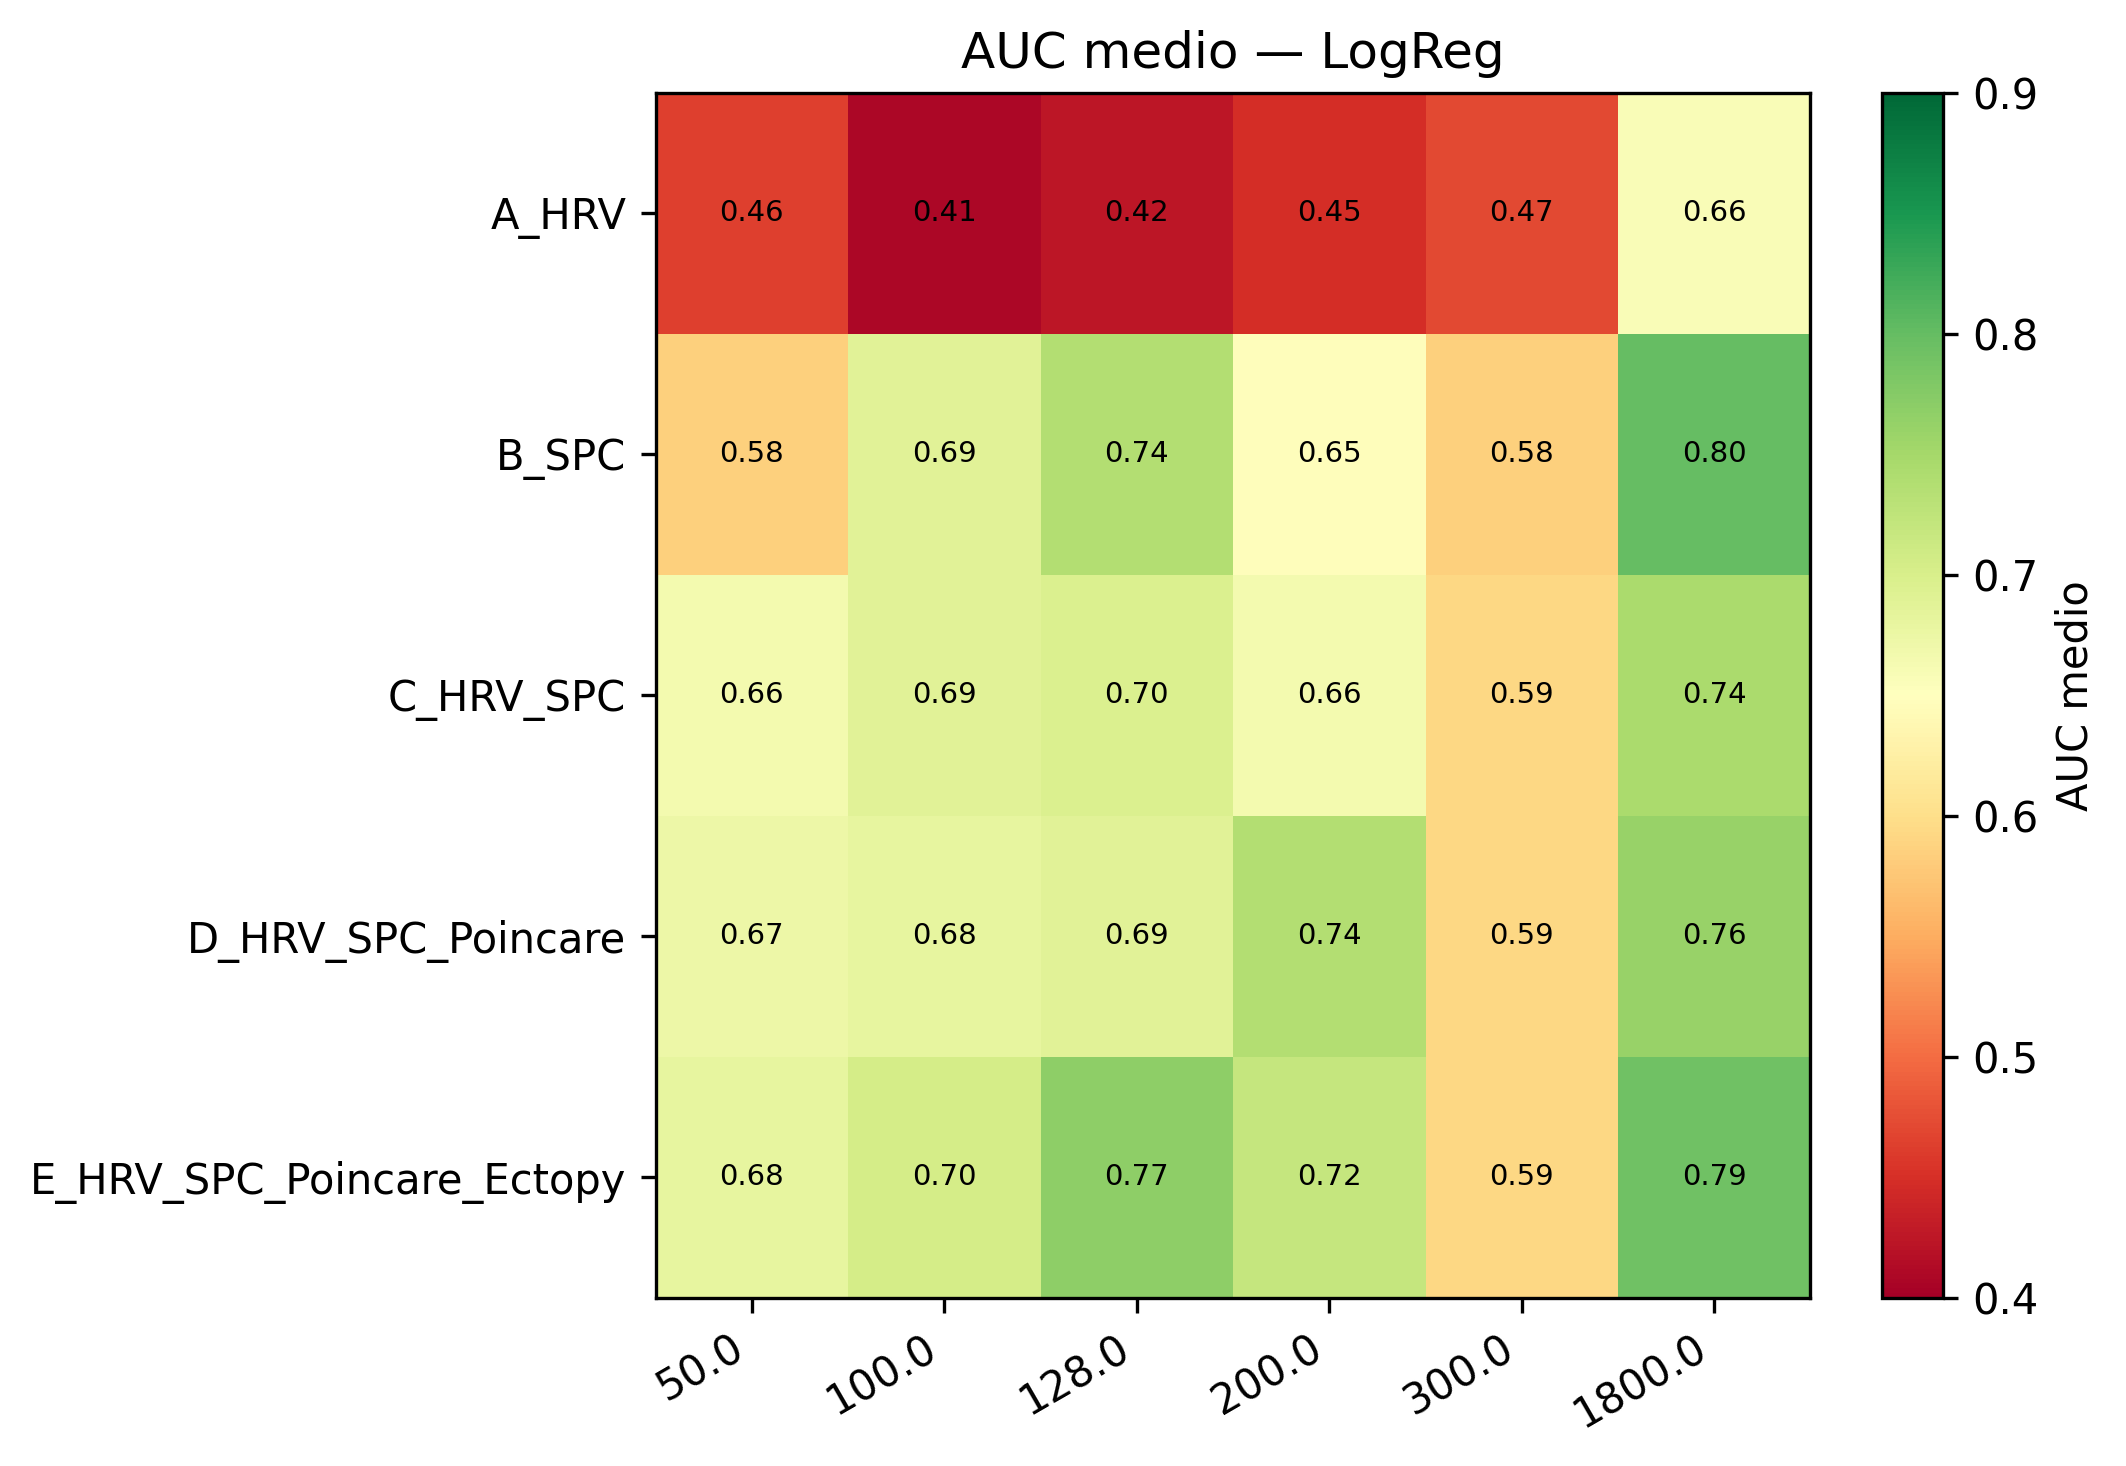

In [14]:
# Ablation: AUC by block across window sizes (heatmap)
png_heatmap = ARTIFACTS_DIR = ROOT / 'artifacts' / 'figures' / 'auc_heatmap_LogReg.png'
if png_heatmap.is_file():
    from IPython.display import Image, display as ipy_display
    print('AUC heatmap (LogReg):')
    ipy_display(Image(str(png_heatmap), width=700))

---
## 12 · Discussion

### Key findings

1. **SPC features substantially outperform HRV alone.**  
   The B_SPC block achieves AUC ≈ 0.776–0.800 (95% CI ≈ [0.70–0.86]) compared to  
   AUC ≈ 0.65 for the reduced HRV block. The Shewhart out-of-control rate  
   (rank-biserial *r* = 0.748, Wilcoxon p = 0.001) is the most consistent  
   individual discriminator.

2. **The pre_onset segment is not distinguished by mean heart rate.**  
   `mean_rr` shows no significant delta (Wilcoxon p = 0.946). The discriminative  
   signal lies in **increased RR variability** (RMSSD median delta +35 ms, p = 0.004)  
   and **SPC instability** — consistent with autonomic dysregulation preceding PAF.

3. **Temporal aggregation reveals a late-loading effect.**  
   Full-record temporal features (late_third, slope_over_time, late_minus_early)  
   yield AUC = 0.864 and PC = 0.920, suggesting that changes are progressive  
   and concentrate in the later portion of the 30-minute pre-onset segment.

4. **Pairwise concordance (PC) is the most clinically aligned metric.**  
   At PC = 0.840–0.880, the model correctly orders 21–22 of 25 pairs  
   (score_pre_onset > score_far_baseline) in cross-validation.

5. **HRV collinearity inflates the feature space without adding information.**  
   RMSSD ≈ SDSD ≈ rr_diff_std ≈ SD1 (|r| ≥ 0.9999). Removing redundant features  
   improved AUC from 0.704 to 0.744 and stabilised LogReg coefficient signs.

---
## 13 · Limitations and Future Work

- **Small sample size (n = 25 pairs):** all 95% CI are wide (~0.16); results are  
  exploratory. No definitive claim of clinical superiority should be made without  
  external replication.

- **Single dataset:** AFPDB is a single public challenge dataset (PhysioNet). External validation  
  on an independent cohort is necessary.

- **Fixed SPC hyperparameters:** h = 7, k = 0.5, λ = 0.2 were set a priori.  
  Nested cross-validation tuning (Phase 4) may improve performance further.

- **Ectopy-like features are RR-inferred only:** no morphological analysis of P-waves  
  was performed. These variables should not be labelled "confirmed PAC" in publications.

- **Lead-time analysis is approximate:** PAF onset is assumed at the end of the  
  30-minute segment; actual onset time within the record is unknown for AFPDB.

- **Decision threshold fixed at 0.5:** no threshold optimisation was performed on  
  test or pooled validation data.

In [15]:
import platform, json, hashlib
import sklearn, scipy, wfdb

print('=== Reproducibility snapshot ===')
print(f'Python       : {platform.python_version()}')
print(f'NumPy        : {np.__version__}')
print(f'Pandas       : {pd.__version__}')
print(f'Scikit-learn : {sklearn.__version__}')
print(f'SciPy        : {scipy.__version__}')
print(f'wfdb         : {wfdb.__version__}')
print(f'random_state : {RANDOM_STATE}')
print(f'decision_threshold: {THRESHOLD}')
print(f'GroupKFold n_splits: 5')
print(f'Bootstrap n: {N_BOOT}')
print(f'CUSUM h=7.0, k=0.5  |  EWMA λ=0.2  |  Shewhart L=3.0')
print(f'Baseline_N_RR: 200  (per-record, not per-fold)')

# Hash of key result files
key_files = [
    TABLES / 'Xy_aggregated_main.csv',
    TABLES / 'v1_paired_delta_analysis.csv',
    TABLES / 'bootstrap_ci_v1_results.csv',
]
print('\nFile integrity (SHA256, first 16 chars):')
for p in key_files:
    if p.is_file():
        h = hashlib.sha256(p.read_bytes()).hexdigest()[:16]
        print(f'  {p.name}: {h}...')

=== Reproducibility snapshot ===
Python       : 3.10.6
NumPy        : 2.2.6
Pandas       : 2.3.2
Scikit-learn : 1.7.2
SciPy        : 1.15.3
wfdb         : 4.3.1
random_state : 42
decision_threshold: 0.5
GroupKFold n_splits: 5
Bootstrap n: 500
CUSUM h=7.0, k=0.5  |  EWMA λ=0.2  |  Shewhart L=3.0
Baseline_N_RR: 200  (per-record, not per-fold)

File integrity (SHA256, first 16 chars):
  Xy_aggregated_main.csv: a7c730f2bd8d73dc...
  v1_paired_delta_analysis.csv: 1a092d30f5791bd8...
  bootstrap_ci_v1_results.csv: ba38310818bc2cdc...


In [16]:
# ── Confirm no n* or *c in Xy_aggregated_main.csv ─────────────────────────
from pathlib import Path
import pandas as pd
p = Path('artifacts/tables/Xy_aggregated_main.csv')
if p.is_file():
    xy = pd.read_csv(p)
    n_star = xy.record_id.str.startswith('n').any()
    c_star = xy.record_id.str.endswith('c').any()
    print(f'File: {p.name}  ({len(xy)} rows)')
    print(f'  Contains n* records : {n_star}  — expected: False')
    print(f'  Contains *c records : {c_star}  — expected: False')
    assert not n_star, 'ERROR: n* records found in Xy_aggregated_main.csv'
    assert not c_star, 'ERROR: *c records found in Xy_aggregated_main.csv'
    print('  AUDIT PASSED: Xy_aggregated_main.csv contains only p* (30-min) records.')
else:
    print('Xy_aggregated_main.csv not found — run run_multiscale_v2.py first.')


File: Xy_aggregated_main.csv  (300 rows)
  Contains n* records : False  — expected: False
  Contains *c records : False  — expected: False
  AUDIT PASSED: Xy_aggregated_main.csv contains only p* (30-min) records.


In [17]:
# ── Dataset audit: export dataset_audit.csv ───────────────────────────────
from afpdb_multiscale.loader import build_main_manifest
import pandas as pd
from pathlib import Path
TABLES = Path('artifacts/tables')
TABLES.mkdir(parents=True, exist_ok=True)

manifest = build_main_manifest()
audit_rows = []
for rec in manifest:
    rid = rec['record_id']
    audit_rows.append({
        'record_id'      : rid,
        'pair_id'        : rec['pair_id'],
        'y'              : rec['y'],
        'role'           : 'pre_onset' if rec['y'] == 1 else 'far_baseline',
        'record_type'    : 'p_30min_main',   # p-odd or p-even 30-min segments
        'is_continuation': False,             # *c records excluded from main task
    })

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(TABLES / 'dataset_audit.csv', index=False)
print(f'Exported: dataset_audit.csv  ({len(audit_df)} records)')
display(audit_df.head(8))


Exported: dataset_audit.csv  (50 records)


,record_id,pair_id,y,role,record_type,is_continuation
0,p01,0,0,far_baseline,p_30min_main,False
1,p02,0,1,pre_onset,p_30min_main,False
2,p03,1,0,far_baseline,p_30min_main,False
3,p04,1,1,pre_onset,p_30min_main,False
4,p05,2,0,far_baseline,p_30min_main,False
5,p06,2,1,pre_onset,p_30min_main,False
6,p07,3,0,far_baseline,p_30min_main,False
7,p08,3,1,pre_onset,p_30min_main,False


In [18]:
# ── Export paper_ready_results.csv ────────────────────────────────────────
from pathlib import Path
import numpy as np, pandas as pd

TABLES  = Path('artifacts/tables')
cv_p    = TABLES / 'cv_summary_main.csv'
ci_p    = TABLES / 'bootstrap_ci_v1_results.csv'
pw_p    = TABLES / 'pairwise_ranking_results.csv'

rows = []
if cv_p.is_file():
    cv  = pd.read_csv(cv_p)
    ci  = pd.read_csv(ci_p) if ci_p.is_file() else pd.DataFrame()
    pw  = pd.read_csv(pw_p) if pw_p.is_file() else pd.DataFrame()

    for _, r in cv.iterrows():
        ci_row = ci[(ci.metric=='auc') & (ci.config==r.get('block',''))] if not ci.empty else pd.DataFrame()
        pc_row = pw[(pw.block==r.get('block','')) & (pw.window_type==r.get('window_type',''))] if not pw.empty else pd.DataFrame()
        rows.append({
            'window_type'   : r.get('window_type',''),
            'window_size'   : r.get('window_size',''),
            'feature_block' : r.get('block',''),
            'model'         : r.get('model',''),
            'auc_mean'      : round(float(r.get('auc_mean', r.get('auc',np.nan))), 4),
            'auc_std'       : round(float(r.get('auc_std',  np.nan)), 4),
            'ci_low'        : round(float(ci_row.ci_low.iloc[0]),  4) if len(ci_row) else np.nan,
            'ci_high'       : round(float(ci_row.ci_high.iloc[0]), 4) if len(ci_row) else np.nan,
            'f1_mean'       : round(float(r.get('f1_mean', r.get('f1', np.nan))), 4),
            'sensitivity'   : round(float(r.get('sens_mean', r.get('sensitivity', np.nan))), 4),
            'specificity'   : round(float(r.get('spec_mean', r.get('specificity', np.nan))), 4),
            'mcc_mean'      : round(float(r.get('mcc_mean', r.get('mcc', np.nan))), 4),
            'pairwise_concordance': round(float(pc_row.pairwise_concordance.mean()), 4)
                                    if len(pc_row) else np.nan,
        })

pr_df = pd.DataFrame(rows).drop_duplicates()
pr_df.to_csv(TABLES / 'paper_ready_results.csv', index=False)
print(f'Exported: paper_ready_results.csv  ({len(pr_df)} rows)')
display(pr_df.sort_values('auc_mean', ascending=False).head(12).round(4))


Exported: paper_ready_results.csv  (60 rows)


,window_type,window_size,feature_block,model,auc_mean,auc_std,ci_low,ci_high,f1_mean,sensitivity,specificity,mcc_mean,pairwise_concordance
23,rr_count,100.0,B_SPC,RandomForest,0.800,0.1659,0.6937,0.8628,0.6929,0.68,0.76,NaN,NaN
27,rr_count,100.0,D_HRV_SPC_Poincare,RandomForest,0.792,0.1418,0.6949,0.8677,0.7170,0.72,0.76,NaN,NaN
29,rr_count,100.0,E_HRV_SPC_Poincare_Ectopy,RandomForest,0.792,0.1588,NaN,NaN,0.6725,0.68,0.72,NaN,NaN
25,rr_count,100.0,C_HRV_SPC,RandomForest,0.776,0.1727,0.6869,0.8605,0.6859,0.68,0.76,NaN,NaN
35,rr_count,128.0,C_HRV_SPC,RandomForest,0.776,0.1422,0.6869,0.8605,0.6707,0.68,0.72,NaN,NaN
33,rr_count,128.0,B_SPC,RandomForest,0.768,0.1900,0.6937,0.8628,0.6796,0.64,0.80,NaN,NaN
26,rr_count,100.0,D_HRV_SPC_Poincare,LogReg,0.768,0.1395,0.6949,0.8677,0.6107,0.60,0.72,NaN,NaN
24,rr_count,100.0,C_HRV_SPC,LogReg,0.768,0.1526,0.6869,0.8605,0.7024,0.72,0.68,NaN,NaN
22,rr_count,100.0,B_SPC,LogReg,0.760,0.1431,0.6937,0.8628,0.6356,0.64,0.68,NaN,NaN
7,full_record,1800.0,D_HRV_SPC_Poincare,RandomForest,0.760,0.0759,0.6949,0.8677,0.6856,0.72,0.72,NaN,0.84


In [19]:
# ── Module reference ──────────────────────────────────────────────────────
# This notebook uses the following modules from src/afpdb_multiscale/:
#   loader.py        — AFPDB record loading, manifest construction
#   feature_blocks.py — HRV block definitions, CorrelationPruner
# Source available at: src/afpdb_multiscale/
from pathlib import Path
src_files = ['loader.py', 'feature_blocks.py']
for f in src_files:
    p = Path(f'src/afpdb_multiscale/{f}')
    size = p.stat().st_size if p.is_file() else 0
    print(f'  {f}: {size} bytes  (exists={p.is_file()})')


  loader.py: 3303 bytes  (exists=True)
  feature_blocks.py: 8151 bytes  (exists=True)
